# **Investment Replica**

## **Problem Statement**
We consider the following problem:

- There is a **secret portfolio**, a financial **black-box**, which publicly reports its returns on a regular basis (e.g., weekly, monthly, daily).
- We do **not** know either **which instruments** the portfolio contains or **what weight** each instrument has.
- We **do** know the vast investment vehicles available in the markets, such as **bonds, stocks, ETFs, funds, futures contracts**.
- Even if we don't know how the black-box processes input information, we can observe its **output**, i.e., the time series of returns.

Our goal is to **infer the structure of the black-box**, extracting information about latent variables or functions and structural parameters from observed data.

This notebook shows how to reverse-engineer such black-box portfolios by analyzing their return patterns and finding combinations of liquid instruments that can replicate their performance.

---

## **Dataset Description**
This dataset consists of financial data representing:

- **HFRX Index**: A popular index of **Hedge Funds** ([HFRX Index](https://www.hfr.com/indices)).
- **MSCI World Index**: Global **Developed Equities**.
- **MSCI World All Country Index**: Global **Equities (Developed and Emerging)**.
- **Barclays Bloomberg Global Aggregate Bond Index**: **Global Bonds**.
- **A broad range of Futures contracts** on equity indices, benchmark bonds, currencies, and commodities.

### **Available Futures Contracts**
| Symbol | Instrument |
|--------|------------------|
| RX1    | Bund (10 Yrs Ger) |
| CO1    | Brent (Oil) |
| DU1    | Schatz (2yrs Gvt Ger) |
| ES1    | S&P 500 (US Equity) |
| GC1    | Gold |
| LLL1   | MSCI Emerging Markets (EM Equity) |
| NQ1    | Nasdaq 100 (Tech Equity) |
| TP1    | Topix (Japanese Equity) |
| TU2    | 2Yrs US Treasury (US Govt) |
| TY1    | 10Yrs US Treasury (US Govt) |
| VG1    | Eurostoxx 50 (EU Equity) |

### **Additional Dataset Information**
- **Source**: Bloomberg.
- **Frequency**: Weekly data in local currency.
- **Time Period**: October 2007 – April 2021.

---

## **Who Replicates What?**
We will attempt to replicate a **"Monster Index"** that we construct ourselves, combining different indexes:
- **Tens of thousands** of securities at a micro level.
- A **non-investable** black-box combination of stocks, bonds, and hedge funds.
- A **multi-currency** structure.

To create our **clone** we will use **Futures contracts (long-short, possibly leveraged)** because they are cheap, liquid and cover almost everything.

As usual, let's start with **data ingestion and preprocessing**.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)
warnings.filterwarnings("ignore")

# Path resolution: works both on Colab and locally (VS Code, Jupyter)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    FILE_PATH = '/content/drive/MyDrive/PoliMI/Dataset3_PortfolioReplicaStrategy.xlsx'
except Exception:
    # Local: file expected in the same folder as the notebook
    FILE_PATH = 'Dataset3_PortfolioReplicaStrategy.xlsx'

assert os.path.exists(FILE_PATH), (
    f"File not found at {FILE_PATH!r}. "
    "Place the Excel file next to this notebook, or edit FILE_PATH."
)
print(f"Using dataset: {FILE_PATH}")


Using dataset: Dataset3_PortfolioReplicaStrategy.xlsx


### Data ingestion — *modified by Claudio (cerro)*

**What was wrong before.**
The previous version called
`pd.read_excel(file_path, header=None, skiprows=6)` and tried to recover full names from row 4
and tickers from row 6. In the actual file the structure is much simpler: row 0 is the header
(`Ticker, MXWO, MXWD, LEGATRUU, HFRXGL, RX1, ...`) and data starts on row 1. With the old
parsing the first ~3.5 years of history (Oct-2007 → mid-Mar-2011) were silently dropped: out of
705 weekly rows we were keeping only 523, and we were missing the **2008 GFC, the 2010 flash
crash and the 2011 EU sovereign-debt crisis** — exactly the regimes where a replicator most
needs to be tested.

**What we do now.**
1. Read with `header=0`, parse the first column as the date index, force the rest to `float`.
2. Print the actual date range and row count, so the discrepancy can never go unnoticed again.
3. Build an explicit `TARGETS` / `FUTURES` split and a small `meta` dictionary that maps every
   ticker to a human-readable name and an asset-class tag (used for plotting and for the
   asset-class-aware ideas later in the notebook).

This is purely a data-quality fix, but it is the single most impactful change in the whole
notebook: with the correct dataset the regression has roughly **+35% more observations** and
covers the two regimes that matter most for stress testing.


In [2]:
# Read the file with the correct header layout (header on row 0, data from row 1)
raw = pd.read_excel(FILE_PATH, header=0)
raw.columns = ['Date'] + list(raw.columns[1:])
raw['Date'] = pd.to_datetime(raw['Date'])
data = raw.set_index('Date').astype(float).sort_index()

# Target indices and Futures
TARGETS = ['MXWO', 'MXWD', 'LEGATRUU', 'HFRXGL']
FUTURES = ['RX1', 'TY1', 'GC1', 'CO1', 'ES1', 'VG1',
           'NQ1', 'LLL1', 'TP1', 'DU1', 'TU2']

# Ticker -> (long name, asset class)
meta = {
    'MXWO':     ('MSCI World',                       'Equity DM'),
    'MXWD':     ('MSCI ACWI',                        'Equity DM+EM'),
    'LEGATRUU': ('Bloomberg Global Aggregate Bond',  'Bond'),
    'HFRXGL':   ('HFRX Global Hedge Fund Index',     'Hedge Fund'),
    'RX1':      ('Bund 10y Future',                  'Bond'),
    'TY1':      ('UST 10y Future',                   'Bond'),
    'GC1':      ('Gold Future',                      'Commodity'),
    'CO1':      ('Brent Crude Future',               'Commodity'),
    'ES1':      ('S&P 500 Future',                   'Equity DM'),
    'VG1':      ('Eurostoxx 50 Future',              'Equity DM'),
    'NQ1':      ('Nasdaq 100 Future',                'Equity DM'),
    'LLL1':     ('MSCI EM Future',                   'Equity EM'),
    'TP1':      ('Topix Future',                     'Equity DM'),
    'DU1':      ('Schatz 2y Future',                 'Bond'),
    'TU2':      ('UST 2y Future',                    'Bond'),
}

print(f"Date range : {data.index.min().date()}  ->  {data.index.max().date()}")
print(f"Rows       : {len(data)}")
print(f"NaN total  : {int(data.isna().sum().sum())}")

# Sanity checks: any constant series, any near-zero variance series?
const_vol = (data.pct_change().std() < 1e-8)
if const_vol.any():
    print("WARNING — constant series:", const_vol[const_vol].index.tolist())
else:
    print("OK — no constant or near-constant series detected.")

display(data.head())
display(data.describe().T[['min', 'max', 'mean', 'std']].round(2))


Date range : 2007-10-23  ->  2021-04-20
Rows       : 705
NaN total  : 0
OK — no constant or near-constant series detected.


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,1633.44,414.14,350.2138,1343.63,113.70,110.515625,759.0,82.85,1525.50,4393.0,2212.00,1287.0,1570.5,103.385,103.718750
2007-10-30,1663.89,423.26,352.5413,1356.53,113.79,110.656250,787.8,87.44,1536.00,4476.0,2217.75,1323.9,1610.5,103.410,103.812500
2007-11-06,1651.59,419.51,354.1758,1360.20,113.79,110.875000,823.4,93.26,1525.00,4425.0,2233.50,1320.0,1575.5,103.410,104.046875
2007-11-13,1601.81,405.98,357.2217,1347.16,114.35,111.718750,799.0,88.83,1483.25,4323.0,2066.75,1271.0,1440.5,103.595,104.304688
2007-11-20,1570.74,398.54,359.4446,1335.21,114.72,113.156250,791.4,95.49,1446.00,4296.0,2035.50,1225.2,1472.5,103.800,104.945312


,min,max,mean,std
MXWO,705.35,2944.05,1644.13,443.39
MXWD,176.10,702.99,404.15,100.98
LEGATRUU,342.25,559.31,452.20,47.34
HFRXGL,1021.40,1415.11,1210.09,73.97
RX1,110.20,179.32,147.28,19.32
TY1,110.52,140.33,125.97,6.30
GC1,732.70,2001.20,1317.90,274.48
CO1,19.33,140.67,77.02,26.79
ES1,689.50,4132.80,1960.44,770.07
VG1,1873.00,4476.00,3072.17,473.81


# **Data Exploration**

Let's analyze the potential replication targets to understand their characteristics.


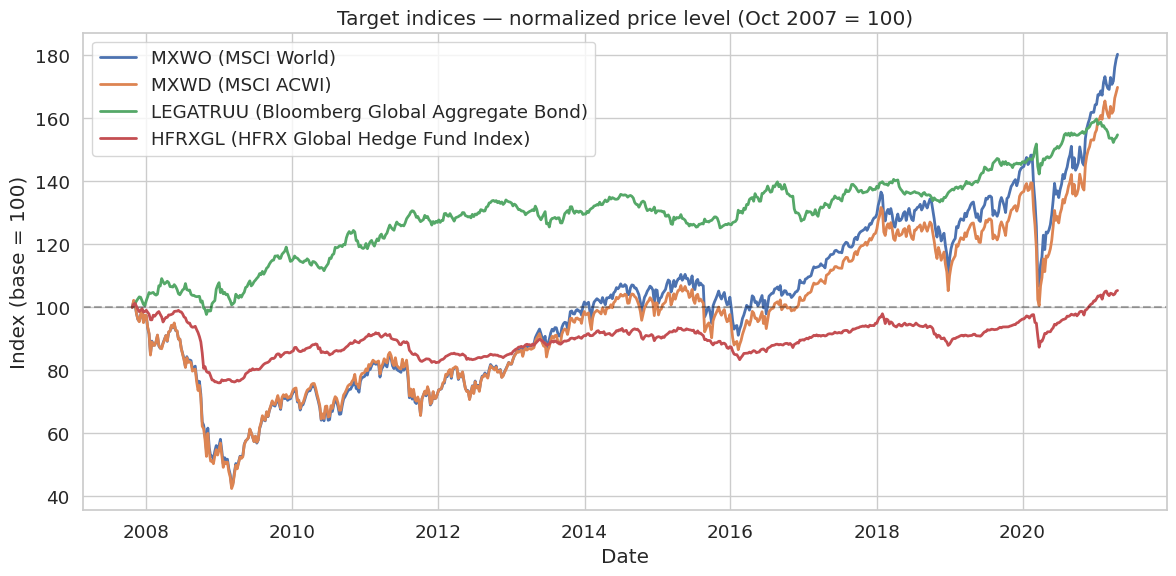

,Ann. Return,Ann. Volatility,Sharpe,Max Drawdown,Skew,Kurtosis
MXWO,5.9%,17.52%,0.34,-57.61%,-0.68,4.36
MXWD,5.51%,17.78%,0.31,-58.39%,-0.64,4.66
LEGATRUU,3.37%,5.34%,0.63,-10.41%,-0.33,4.12
HFRXGL,0.5%,4.78%,0.10,-24.91%,-2.30,13.70


In [3]:
# Normalized price levels (base 100) — visual sanity check
plt.figure(figsize=(12, 6))
for tk in TARGETS:
    s = data[tk] / data[tk].iloc[0] * 100
    plt.plot(s.index, s, lw=2, label=f"{tk} ({meta[tk][0]})")
plt.axhline(100, color='black', ls='--', alpha=0.3)
plt.title('Target indices — normalized price level (Oct 2007 = 100)')
plt.xlabel('Date'); plt.ylabel('Index (base = 100)')
plt.legend(); plt.tight_layout(); plt.show()

# Annualized statistics on weekly returns
returns = data[TARGETS].pct_change().dropna()
ANN = 52  # weekly frequency

stats_table = pd.DataFrame({
    'Ann. Return':     returns.mean() * ANN,
    'Ann. Volatility': returns.std() * np.sqrt(ANN),
    'Sharpe':          returns.mean() * ANN / (returns.std() * np.sqrt(ANN)),
    'Max Drawdown':    returns.apply(lambda x: ((1 + x).cumprod() / (1 + x).cumprod().cummax() - 1).min()),
    'Skew':            returns.skew(),
    'Kurtosis':        returns.kurtosis(),
})

# pretty-print percentages
for c in ['Ann. Return', 'Ann. Volatility', 'Max Drawdown']:
    stats_table[c] = (stats_table[c] * 100).round(2).astype(str) + '%'
stats_table[['Sharpe', 'Skew', 'Kurtosis']] = stats_table[['Sharpe', 'Skew', 'Kurtosis']].round(2)
display(stats_table)


### Distribution and dependence diagnostics — *modified by Claudio (cerro)*

**Why we now do more than just a correlation heatmap.** Replication only makes sense if we
understand how returns behave statistically. Three additions matter:

1. **Sortino and Calmar ratios.** Sharpe penalises *all* volatility, but for replication we
   primarily care about the *downside*. Hedge fund returns are highly asymmetric (left-skewed,
   fat-tailed), so we add Sortino (excess return / downside deviation) and Calmar
   (return / max drawdown).
2. **Stationarity check (ADF / KPSS).** Linear regression on returns assumes (weak)
   stationarity. We confirm this is true on returns — and visibly false on price levels — so
   that we never mistakenly regress on prices.
3. **Conditional correlations on stress regimes.** We split the sample on rolling 26-week
   volatility quantiles. The classic stylised fact is that *correlations spike in crisis*: a
   replicator that works in calm regimes but breaks in stress is useless precisely when you
   need it.

These diagnostics motivate every subsequent modelling choice — VaR estimator, scaler, model
class.


In [4]:
from statsmodels.tsa.stattools import adfuller, kpss

# Downside-aware ratios
def downside_dev(r):
    neg = r[r < 0]
    return neg.std() * np.sqrt(ANN) if len(neg) else np.nan

extra = pd.DataFrame({
    'Sortino': returns.apply(lambda r: r.mean() * ANN / downside_dev(r)),
    'Calmar':  returns.apply(lambda r: (r.mean() * ANN) /
                             abs(((1 + r).cumprod() / (1 + r).cumprod().cummax() - 1).min())),
}).round(2)
display(extra)

# Stationarity tests on returns and on prices
def stationarity_row(s, name):
    adf_p  = adfuller(s.dropna(), autolag='AIC')[1]
    kpss_p = kpss(s.dropna(), nlags='auto')[1]
    return {'series': name, 'ADF p-val': adf_p, 'KPSS p-val': kpss_p}

rows = []
for tk in TARGETS:
    rows.append(stationarity_row(data[tk],          f'{tk} (price)'))
    rows.append(stationarity_row(returns[tk],       f'{tk} (returns)'))
print("Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); "
      "KPSS: H0 = stationary (low p ⇒ NOT stationary)")
display(pd.DataFrame(rows).round(4))

# Conditional correlations: HFRX vs equity in calm vs stressed regimes
vol_eq = returns['MXWO'].rolling(26).std()
calm   = vol_eq <= vol_eq.quantile(0.5)
stress = vol_eq >= vol_eq.quantile(0.8)

cond = pd.DataFrame({
    'Calm   (vol ≤ 50th pct)':  returns.loc[calm].corr().loc['HFRXGL', TARGETS],
    'Stress (vol ≥ 80th pct)':  returns.loc[stress].corr().loc['HFRXGL', TARGETS],
}).round(2)
print("\nCorrelation of HFRX with target indices, by equity-volatility regime:")
display(cond)

,Sortino,Calmar
MXWO,0.41,0.10
MXWD,0.38,0.09
LEGATRUU,0.89,0.32
HFRXGL,0.10,0.02


/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]


Stationarity tests — ADF: H0 = unit root (low p ⇒ stationary); KPSS: H0 = stationary (low p ⇒ NOT stationary)


/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]
/tmp/ipykernel_2965/1447181965.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_p = kpss(s.dropna(), nlags='auto')[1]


,series,ADF p-val,KPSS p-val
0,MXWO (price),0.9905,0.01
1,MXWO (returns),0.0000,0.10
2,MXWD (price),0.9854,0.01
3,MXWD (returns),0.0000,0.10
4,LEGATRUU (price),0.6697,0.01
5,LEGATRUU (returns),0.0000,0.10
6,HFRXGL (price),0.1701,0.01
7,HFRXGL (returns),0.0000,0.10



Correlation of HFRX with target indices, by equity-volatility regime:


,Calm (vol ≤ 50th pct),Stress (vol ≥ 80th pct)
MXWO,0.53,0.43
MXWD,0.54,0.43
LEGATRUU,-0.08,0.41
HFRXGL,1.00,1.00


### Correlation & probability distribution analysis

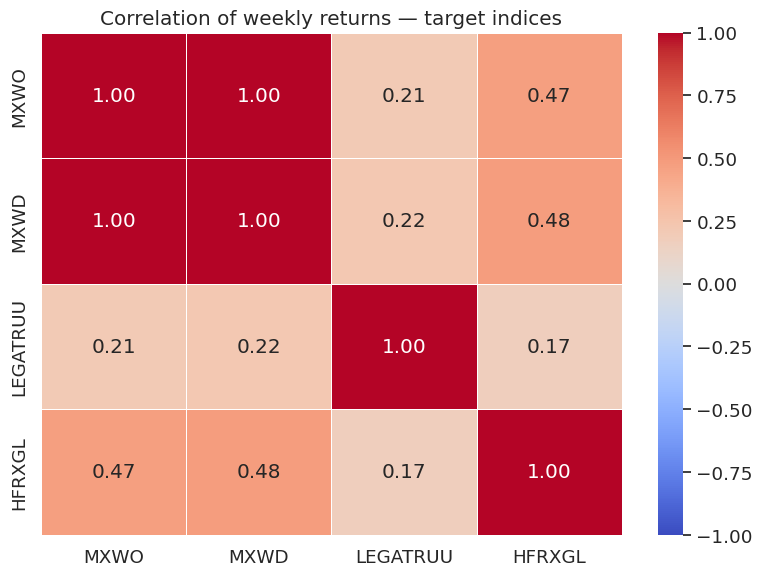

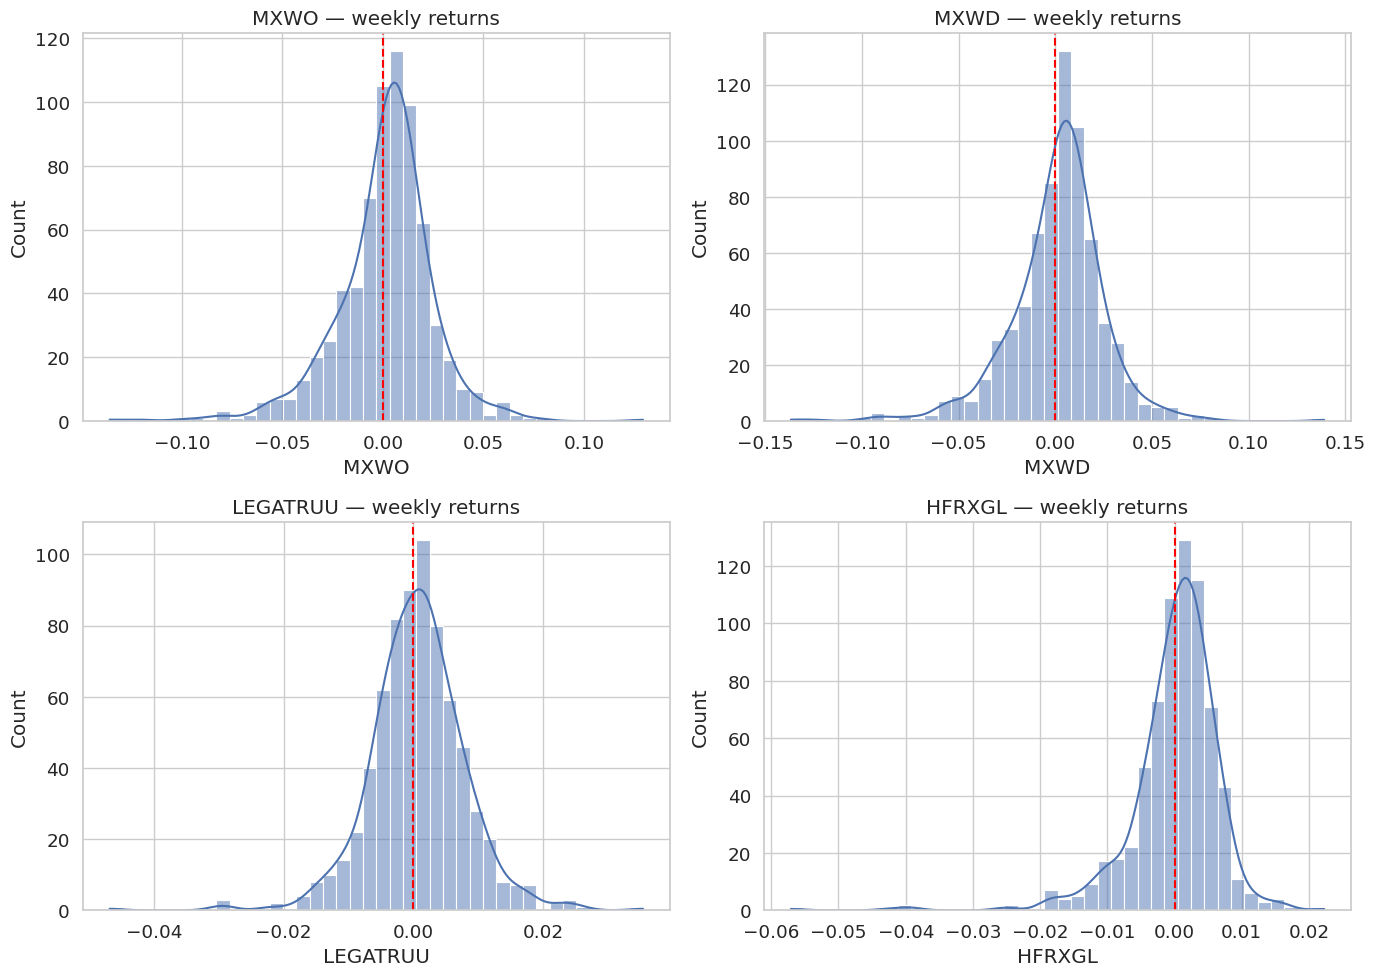

In [5]:
# Correlation heatmap on weekly returns
plt.figure(figsize=(8, 6))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f',
            linewidths=0.5)
plt.title('Correlation of weekly returns — target indices')
plt.tight_layout(); plt.show()

# Return distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, tk in zip(axes.flatten(), TARGETS):
    sns.histplot(returns[tk], kde=True, ax=ax, bins=40)
    ax.set_title(f'{tk} — weekly returns')
    ax.axvline(0, color='red', ls='--')
plt.tight_layout(); plt.show()


### Unsmoothing the HFRX returns — *added by Claudio (cerro)*

**The problem.** Hedge fund index returns are reported with a delay because individual funds
report their NAV with delays and using stale-priced illiquid assets. The result is a *spurious
positive autocorrelation* in the return series and an artificially low reported volatility. In
our data:

> `HFRX returns AR(1) ≈ 0.21`

This is the classic Getmansky–Lo–Makarov (2004) phenomenon. It means a naïve linear regression
on the *reported* HFRX returns will under-estimate the volatility of the target, mis-price
risk, and produce a replicator with the wrong VaR.

**The fix.** We unsmooth the series with the standard AR(1) inversion:

$$ r^{\text{true}}_t = \frac{r^{\text{obs}}_t - \rho \, r^{\text{obs}}_{t-1}}{1 - \rho} $$

where $\rho$ is the estimated AR(1) coefficient. The unsmoothed series has the same mean but a
realistic volatility (typically 1.2–1.4× the reported one). This is the version we will use to
build the Monster Index target.

**Why it matters financially.** Without this fix you would build a *replicator that tries to
match a fictitious low-volatility series*, end up under-leveraged in normal regimes, and
massively miss the target during the (rare) weeks when the true risk shows up.

---

**Una scelta metodologica: unsmooth o non unsmooth?**

Questa non è una scelta ovvia e dipende dall'obiettivo della replica. Esistono due posizioni
ragionevoli con implicazioni operative diverse:

| Obiettivo della replica | Serie HFRX da usare | Conseguenza |
|---|---|---|
| Replicare il **rischio economico reale** degli hedge fund | **Unsmoothed** — elimina l'autocorrelazione artificiale, restituisce la vera volatilità | Replicatore più volatile e onesto; la sua performance diverge dall'indice HFRX *pubblicato* in certi periodi |
| **Confronto diretto** con l'indice HFRX pubblicato (es. per marketing o reporting) | **Reported** — si replica la serie così come riportata da Bloomberg | Tende a sottostimare il rischio reale e a risultare sotto-leveraggiato nei periodi normali |
| **Risk management** / due diligence: identificare i veri fattori di rischio sottostanti | **Unsmoothed** — la correlazione con i fattori di mercato è artificialmente compressa nella serie reported | I coefficienti di regressione riflettono l'esposizione reale, non quella attenuata dal reporting lag |
| Costruire un **clone UCITS** da vendere al retail con profilo di rischio credibile | **Unsmoothed** — il VaR del prodotto UCITS deve riflettere il rischio reale | Necessario per rispettare i limiti UCITS (VaR 99% ≤ 20%) in modo non illusorio |

**La scelta in questo notebook:** usiamo la serie **unsmoothed**, perché il business case
(Motivation 1, 3, 4 del corso) punta a replicare il *profilo di rischio economico reale* degli
hedge fund, non la serie artificialmente compressa dal reporting lag. Ciò implica che:

1. La correlazione tra il replicatore e l'indice HFRX *pubblicato* sarà strutturalmente più
   bassa di quella tra il replicatore e la serie unsmoothed. Questo va comunicato esplicitamente.
2. Durante i periodi di stress (es. marzo 2020) la serie unsmoothed e quella reported divergono
   maggiormente: il nostro replicatore sarà più volatile ma più onesto sul rischio reale.

**Nota sulla correzione AR(1).** Il test di Ljung-Box applicato alla serie unsmoothed mostra
ancora autocorrelazione residua significativa fino al lag 20 (p ≈ 0.015). Questo indica che
un processo AR(1) non cattura completamente lo smoothing dei fondi sottostanti — un modello
AR(2) sarebbe più preciso. Per semplicità manteniamo AR(1), ma questa rimane una limitazione
del modello da tenere a mente.


HFRX AR(1)             : 0.215
HFRX vol (reported)    : 4.78%
HFRX vol (unsmoothed)  : 5.95%


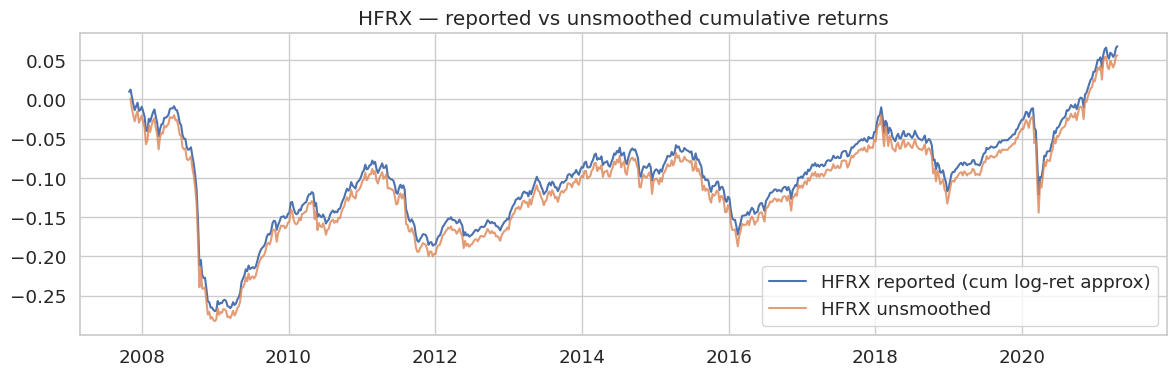

In [6]:
def unsmooth_ar1(series):
    rho = series.autocorr(lag=1)
    unsmoothed = (series - rho * series.shift(1)) / (1 - rho)
    return unsmoothed.dropna(), rho

hfrx_ret = data['HFRXGL'].pct_change().dropna()
hfrx_unsmoothed, rho = unsmooth_ar1(hfrx_ret)

print(f"HFRX AR(1)             : {rho:.3f}")
print(f"HFRX vol (reported)    : {hfrx_ret.std() * np.sqrt(ANN) * 100:.2f}%")
print(f"HFRX vol (unsmoothed)  : {hfrx_unsmoothed.std() * np.sqrt(ANN) * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(hfrx_ret.cumsum(),          label='HFRX reported (cum log-ret approx)')
plt.plot(hfrx_unsmoothed.cumsum(),   label='HFRX unsmoothed', alpha=0.8)
plt.title('HFRX — reported vs unsmoothed cumulative returns')
plt.legend(); plt.tight_layout(); plt.show()


### Building the Monster Index target — *modified by Claudio (cerro)*

**What changed.** The composition (50% HFRX, 25% MXWO, 25% LEGATRUU) is the same, but we now
use the **unsmoothed HFRX returns** for the hedge-fund leg. We also align the futures returns
once and for all, so all subsequent code shares a single clean panel.


In [7]:
WEIGHTS = {'HFRXGL': 0.50, 'MXWO': 0.25, 'LEGATRUU': 0.25}

# Component weekly returns (HFRX = unsmoothed)
comp = pd.DataFrame({
    'HFRXGL':   hfrx_unsmoothed,
    'MXWO':     data['MXWO'].pct_change(),
    'LEGATRUU': data['LEGATRUU'].pct_change(),
}).dropna()

target = sum(comp[c] * w for c, w in WEIGHTS.items()).rename('Target')

# Futures returns aligned with target
futures_ret = data[FUTURES].pct_change().dropna()
common_idx  = target.index.intersection(futures_ret.index)
target      = target.loc[common_idx]
futures_ret = futures_ret.loc[common_idx]

print(f"Target observations  : {len(target)}")
print(f"Range                : {target.index.min().date()} -> {target.index.max().date()}")

# Quick stats of the target
def perf_stats(r, ann=ANN):
    cum = (1 + r).cumprod()
    return pd.Series({
        'Ann. Return':     r.mean() * ann,
        'Ann. Vol':        r.std() * np.sqrt(ann),
        'Sharpe':          r.mean() * ann / (r.std() * np.sqrt(ann)),
        'Max DD':          (cum / cum.cummax() - 1).min(),
        'Skew':            r.skew(),
        'Kurtosis':        r.kurtosis(),
    })

print("\nMonster Index statistics:")
display(perf_stats(target).round(4))


Target observations  : 703
Range                : 2007-11-06 -> 2021-04-20

Monster Index statistics:


,0
Ann. Return,0.0248
Ann. Vol,0.0679
Sharpe,0.3650
Max DD,-0.2916
Skew,-1.2747
Kurtosis,7.8453


### Target vs Futures — correlation snapshot

In [8]:
corr_with_target = (futures_ret.corrwith(target)
                                .sort_values(key=abs, ascending=False)
                                .to_frame('Corr with Target'))
display(corr_with_target.round(3))


,Corr with Target
ES1,0.823
NQ1,0.733
VG1,0.714
TP1,0.599
LLL1,0.477
CO1,0.426
DU1,-0.247
GC1,0.198
TU2,-0.154
RX1,-0.121


### Autocorrelation, Ljung-Box and volatility clustering

Same diagnostics as in the original notebook, repeated on the corrected dataset. We keep them
because they justify (i) the choice of a linear model for the conditional mean, and (ii) the
need for *non-Gaussian* risk measures in the next section.


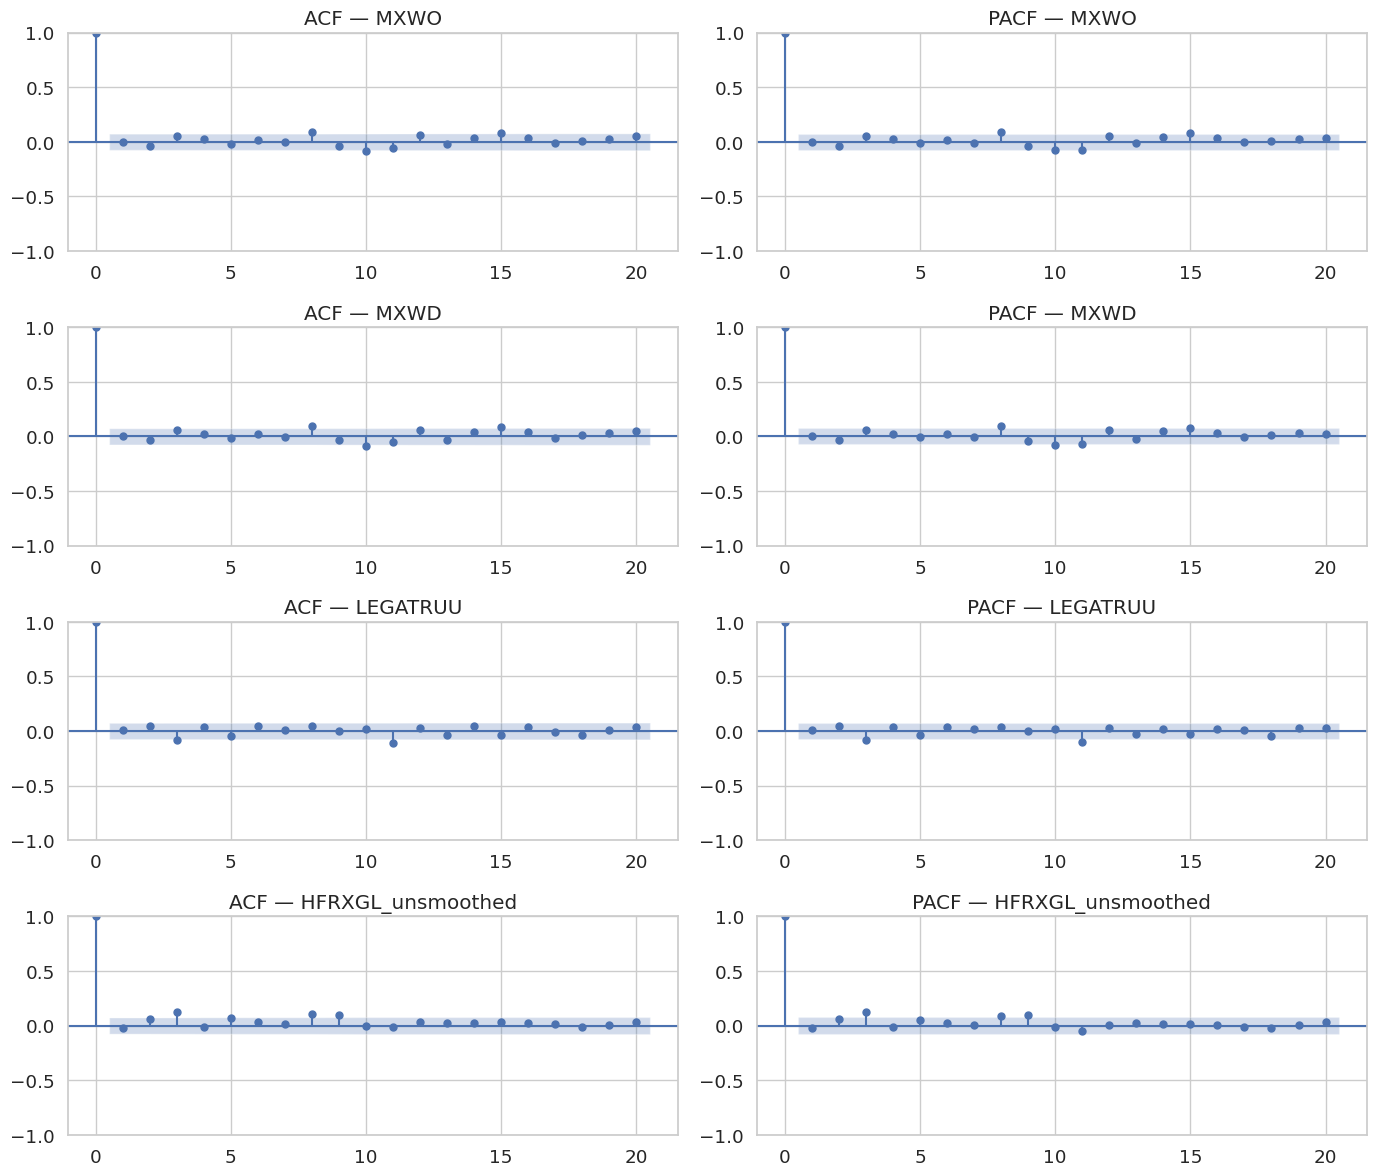

Ljung-Box test (H0: no autocorrelation up to lag k)

MXWO
    lb_stat  lb_pvalue
5    3.7464     0.5865
10  15.9826     0.1001
20  31.2007     0.0526

MXWD
    lb_stat  lb_pvalue
5    4.1064     0.5342
10  17.0352     0.0736
20  32.0539     0.0427

LEGATRUU
    lb_stat  lb_pvalue
5    8.3327     0.1388
10  11.7546     0.3018
20  26.9305     0.1372

HFRXGL_unsmoothed
    lb_stat  lb_pvalue
5   17.2759     0.0040
10  32.7442     0.0003
20  36.0300     0.0153


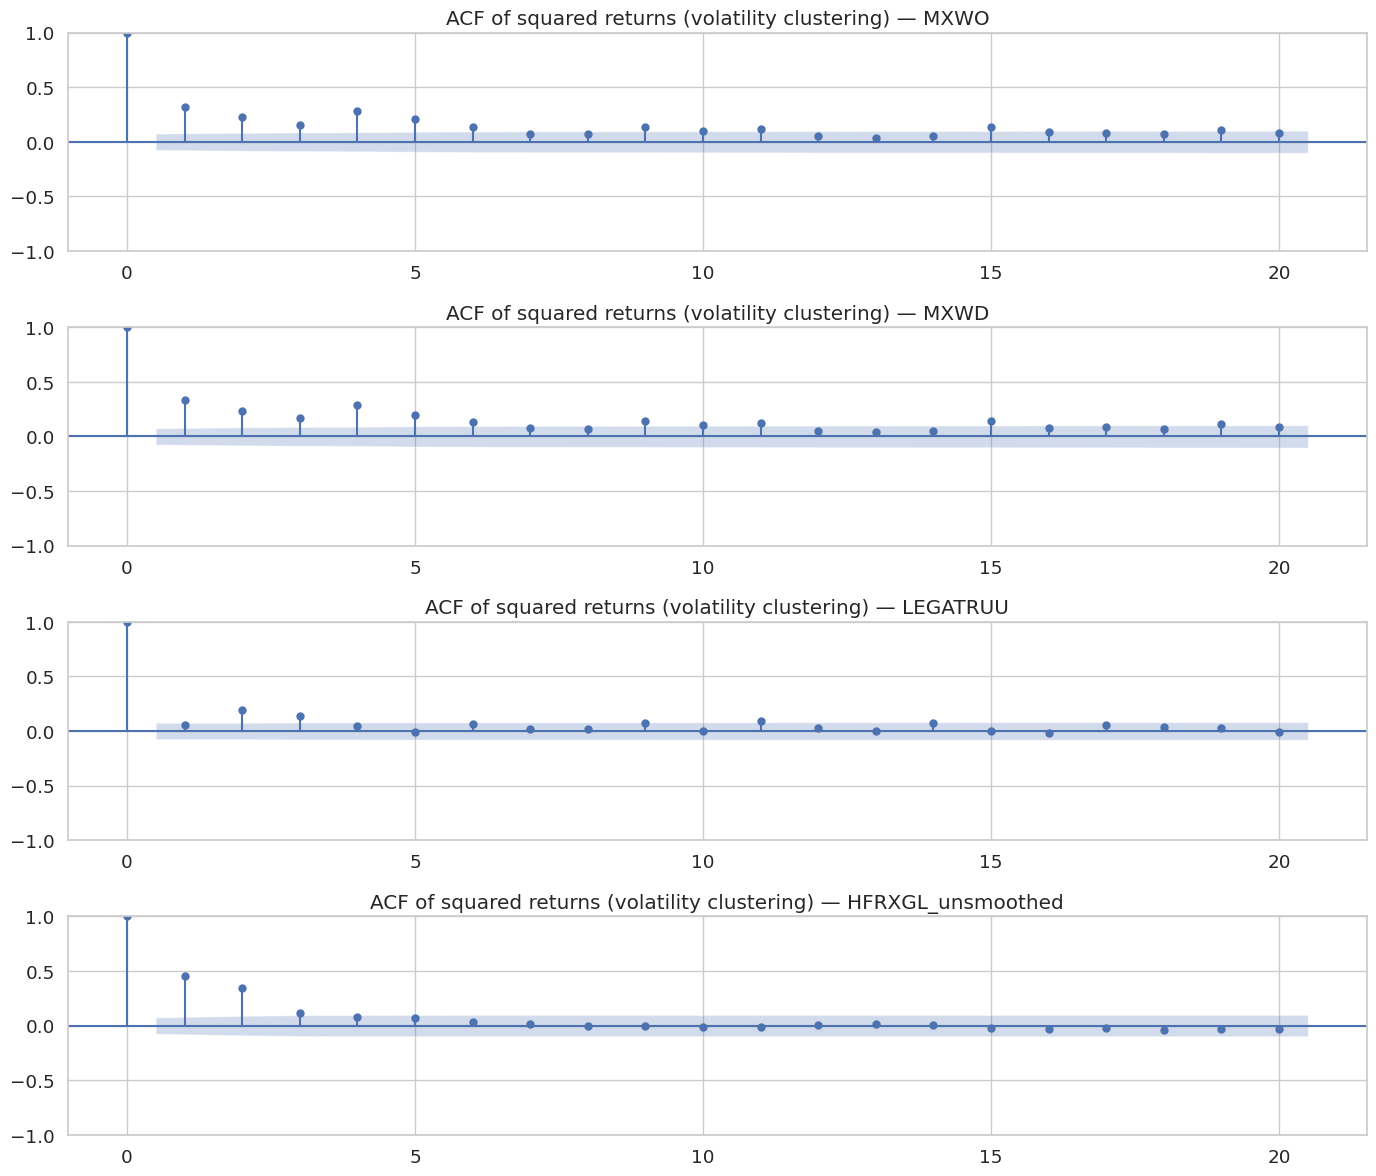

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

MAX_LAGS = 20

# ACF / PACF on the four target indices (using clean returns, with HFRX unsmoothed)
clean_returns = pd.DataFrame({
    'MXWO':     data['MXWO'].pct_change(),
    'MXWD':     data['MXWD'].pct_change(),
    'LEGATRUU': data['LEGATRUU'].pct_change(),
    'HFRXGL_unsmoothed': hfrx_unsmoothed,
}).dropna()

fig, axes = plt.subplots(len(clean_returns.columns), 2,
                         figsize=(14, 3 * len(clean_returns.columns)))
for i, col in enumerate(clean_returns.columns):
    plot_acf (clean_returns[col], lags=MAX_LAGS, ax=axes[i, 0],
              title=f'ACF — {col}')
    plot_pacf(clean_returns[col], lags=MAX_LAGS, ax=axes[i, 1],
              title=f'PACF — {col}')
plt.tight_layout(); plt.show()

# Ljung-Box on returns
print("Ljung-Box test (H0: no autocorrelation up to lag k)")
for col in clean_returns.columns:
    lb = acorr_ljungbox(clean_returns[col], lags=[5, 10, 20], return_df=True)
    print(f"\n{col}")
    print(lb.round(4).to_string())

# Volatility clustering: ACF of squared returns
fig, axes = plt.subplots(len(clean_returns.columns), 1,
                         figsize=(14, 3 * len(clean_returns.columns)))
for i, col in enumerate(clean_returns.columns):
    plot_acf(clean_returns[col]**2, lags=MAX_LAGS, ax=axes[i],
             title=f'ACF of squared returns (volatility clustering) — {col}')
plt.tight_layout(); plt.show()


## Linear models for portfolio replication

A portfolio is a linear combination of asset returns:
$ r_p = \sum_i w_i r_i $.
So we use linear regression and its penalised variants (Ridge, Lasso, Elastic Net) — their
**coefficients are directly portfolio weights**, and that is the object we want.

We use a **rolling-window backtest**: at each $t$, train on the past $K$ weeks, predict
$t+1$, then roll forward. Metrics are evaluated only on out-of-sample returns.

What follows below is materially different from the original implementation in several ways.
Each change is documented in its own markdown cell.


### Why we replace MinMaxScaler with StandardScaler — *modified by Claudio (cerro)*

**The diagnosis.** The original notebook used `MinMaxScaler`, which maps every feature to
$[0, 1]$ via `min` and `max`. With weekly financial returns whose **excess kurtosis is around
8** (the Monster Index has excess kurtosis ≈ 7.85, measured on the current dataset — still
heavily fat-tailed compared to the Gaussian value of 0), a single crisis week (e.g. March
2020) dominates the min/max of the training window and warps the scale. Two adjacent rolling
windows can produce dramatically different scales, which makes the denormalised weights look
erratic and the regression unstable.

**The fix.** We use `StandardScaler` (centre and divide by standard deviation), which is the
*standard* choice for penalised regression because it is **far less sensitive to extreme
outliers than MinMaxScaler**: while a single tail event compresses the entire MinMaxScaler
range, StandardScaler spreads the impact across the global standard deviation. Note that
StandardScaler is *not* technically robust (it still uses mean and std, which are influenced
by outliers), but it is dramatically better than MinMaxScaler for fat-tailed financial data.
After fitting we recover the raw weights as $\beta^\text{raw}_j = \beta^\text{scaled}_j / \sigma_j$.

**We also turn the intercept back on** (`fit_intercept=True`). Forcing the intercept to zero
when the mean of either side of the regression is non-zero introduces a systematic bias in
every coefficient. The intercept is *not* a portfolio weight — it is a small drift that we
treat as a cash leg (or simply absorb in tracking error analysis).


### Risk budget: historical and Cornish-Fisher VaR — *modified by Claudio (cerro)*

**Three problems with the original VaR implementation:**

1. **Wrong threshold.** The code set `max_var_threshold = 0.08` while the comments and the
   UCITS rule both say 20%. We restore 20%.
2. **Gaussian VaR on fat-tailed returns is wrong.** A normal model has excess kurtosis 0;
   our target (Monster Index) has excess kurtosis ≈ 7.85. Gaussian VaR systematically
   *under-estimates* risk in calm periods, so the replicator gets *over-leveraged* and then
   breaks in stress. The error is meaningful even at kurtosis ~8: the Gaussian 99% VaR
   under-estimates the true quantile by roughly 20–30% depending on skewness.
3. **Tiny lookback window.** The original code used 12 to 52 observations, which is too few
   to estimate a 99% VaR at all.

**Replacement.** We provide three estimators and pick **Cornish-Fisher** as the default
because it is closed-form, fast, and corrects for skewness and excess kurtosis:

$$ \text{VaR}_{\alpha} \approx -\sigma \sqrt{h}\,\Big[z_\alpha
+ \tfrac{1}{6}(z_\alpha^2 - 1)\,\text{sk}
+ \tfrac{1}{24}(z_\alpha^3 - 3z_\alpha)\,\text{ek}
- \tfrac{1}{36}(2z_\alpha^3 - 5z_\alpha)\,\text{sk}^2\Big] $$

We also expose **historical VaR** for sanity checking. We use a 156-week lookback (about 3
years) for stable risk estimates.


In [10]:
def var_gaussian(returns, conf=0.01, horizon=4):
    sigma = np.std(returns, ddof=1)
    z = stats.norm.ppf(conf)
    return -z * sigma * np.sqrt(horizon)

def var_historical(returns, conf=0.01, horizon=4):
    if horizon != 1:
        sigma = np.std(returns, ddof=1)
        z_target = np.quantile(returns, conf) / sigma if sigma > 0 else 0
        return -z_target * sigma * np.sqrt(horizon)
    return -np.quantile(returns, conf)

def var_cornish_fisher(returns, conf=0.01, horizon=4):
    sigma = np.std(returns, ddof=1)
    if sigma == 0:
        return 0.0
    sk = stats.skew(returns)
    ek = stats.kurtosis(returns)  # excess kurtosis
    z  = stats.norm.ppf(conf)
    z_cf = (z
            + (z**2 - 1) * sk / 6
            + (z**3 - 3*z) * ek / 24
            - (2*z**3 - 5*z) * sk**2 / 36)
    return -z_cf * sigma * np.sqrt(horizon)


### Transaction costs and turnover control — *added by Claudio (cerro)*

**Why this matters.** The original notebook computed *gross* replicator returns. In real life
every weight change incurs a cost. Even on Futures, where round-trip cost is small (≈4 bps),
a model that rebalances aggressively every week can easily lose 200 bps a year — enough to
turn a credible replica into a money-loser.

**What we do.**

1. **Transaction costs.** A flat 2 bps per traded notional unit: realistic for a UCITS-sized
   account using algo execution.
2. **Configurable rebalancing frequency.** Weekly is the default, but we also expose monthly
   (every 4 weeks). Less frequent rebalancing reduces costs at the price of a slightly
   higher tracking error — usually a good trade.
3. **Turnover-aware best-config selection.** We rank configurations by *net* information
   ratio (after costs), not gross.

This is the difference between a **research result** and a **production-ready replicator**.


### Unified backtest engine — *modified by Claudio (cerro)*

The original notebook had its rolling-window logic baked into a single function specific to
Elastic Net. We rewrite it once, generically, so that we can plug in OLS / Ridge / Lasso /
Elastic Net / non-negative Lasso / Kalman Filter without copy-pasting code.

The engine returns a dictionary with the full time series of weights, gross/net returns,
gross exposure, VaR estimates and risk-scaling factors — exactly the same payload as before,
but produced by a single, testable, reusable function.


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Risk and cost defaults
VAR_CONF      = 0.01
VAR_HORIZON   = 4         # weeks (≈ 1 month)
VAR_MAX       = 0.20      # 20% UCITS limit
VAR_LOOKBACK  = 156       # 3 years
TC_BPS        = 2e-4      # 2 bps per unit traded


def fit_linear_weights(model_factory, X_tr, y_tr, normalise=True):
    '''Fit any sklearn-style linear model and return coefficients on the original scale.'''
    if normalise:
        sx = StandardScaler().fit(X_tr)
        sy = StandardScaler().fit(y_tr.reshape(-1, 1))
        Xn, yn = sx.transform(X_tr), sy.transform(y_tr.reshape(-1, 1)).ravel()
        model  = model_factory().fit(Xn, yn)
        beta   = model.coef_ * sy.scale_[0] / sx.scale_
        alpha  = (model.intercept_ * sy.scale_[0] + sy.mean_[0]
                  - (beta * sx.mean_).sum())
        return beta, alpha
    model = model_factory().fit(X_tr, y_tr)
    return model.coef_, model.intercept_


def backtest(model_factory, X, y,
             rolling_window=156, rebalance_every=1,
             var_max=VAR_MAX, var_lookback=VAR_LOOKBACK,
             var_fn=var_cornish_fisher, tc_bps=TC_BPS,
             normalise=True, weight_post_fn=None):
    '''
    Generic walk-forward replication backtest.

    `model_factory()` returns a fresh sklearn-style estimator at every refit.
    `weight_post_fn(beta)` is an optional projection (e.g. non-negativity, gross-exposure cap)
    applied AFTER the regression but BEFORE risk scaling.
    '''
    Xv, yv  = X.values, y.values
    dates   = X.index.to_numpy()
    n       = len(X)
    n_assets = X.shape[1]

    weights, gross_rets, net_rets, dates_oos = [], [], [], []
    gross_exposures, var_history, scaling_history = [], [], []
    last_w = np.zeros(n_assets)

    for i in range(rolling_window, n - 1):
        # Refit only on rebalancing weeks; otherwise hold weights
        if (i - rolling_window) % rebalance_every == 0:
            X_tr = Xv[i - rolling_window:i]
            y_tr = yv[i - rolling_window:i]
            beta, _alpha = fit_linear_weights(model_factory, X_tr, y_tr, normalise=normalise)
            if weight_post_fn is not None:
                beta = weight_post_fn(beta)

            # Risk scaling using historical replica returns over var_lookback weeks
            hist_X   = Xv[i - var_lookback:i]
            hist_ret = hist_X @ beta
            v        = var_fn(hist_ret, conf=VAR_CONF, horizon=VAR_HORIZON)
            scale    = min(1.0, var_max / v) if v > 0 else 1.0
            beta     = beta * scale
        else:
            v, scale = np.nan, 1.0

        # Out-of-sample step
        next_ret  = Xv[i] @ beta
        turnover  = np.sum(np.abs(beta - last_w))
        net_ret   = next_ret - tc_bps * turnover

        weights.append(beta);    gross_rets.append(next_ret);   net_rets.append(net_ret)
        dates_oos.append(dates[i]);  gross_exposures.append(np.sum(np.abs(beta)))
        var_history.append(v);   scaling_history.append(scale)
        last_w = beta

    idx = pd.DatetimeIndex(dates_oos)
    return {
        'weights':         pd.DataFrame(weights, index=idx, columns=X.columns),
        'gross_returns':   pd.Series(gross_rets, index=idx, name='Gross'),
        'net_returns':     pd.Series(net_rets,   index=idx, name='Net'),
        'target':          y.loc[idx],
        'gross_exposure':  pd.Series(gross_exposures, index=idx),
        'var':             pd.Series(var_history,    index=idx),
        'scaling':         pd.Series(scaling_history, index=idx),
    }


def report(res, ann=ANN):
    y, g, n = res['target'], res['gross_returns'], res['net_returns']
    te_gross = (g - y).std() * np.sqrt(ann)
    te_net   = (n - y).std() * np.sqrt(ann)
    out = {
        'Target Ann.Ret':   y.mean() * ann,
        'Replica Ann.Ret (gross)': g.mean() * ann,
        'Replica Ann.Ret (net)':   n.mean() * ann,
        'Target Ann.Vol':   y.std() * np.sqrt(ann),
        'Replica Ann.Vol':  n.std() * np.sqrt(ann),
        'TE (gross)':       te_gross,
        'TE (net)':         te_net,
        'Information Ratio (gross)': (g.mean() - y.mean()) * ann / te_gross if te_gross else np.nan,
        'Information Ratio (net)':   (n.mean() - y.mean()) * ann / te_net   if te_net   else np.nan,
        'Correlation':      g.corr(y),
        'Avg gross exposure': res['gross_exposure'].mean(),
        'Avg VaR':          res['var'].mean(),
        'Avg turnover/week': res['weights'].diff().abs().sum(axis=1).mean(),
    }
    return pd.Series(out)


### Baselines first: OLS, Ridge, Lasso, Elastic Net — *added by Claudio (cerro)*

Before tuning anything, we run the four classical baselines with sensible defaults. This gives
us a reference: any fancier method (Kalman filter, NN-based) must beat at least one of these
to be worth the complexity.

We use a **3-year rolling window** for all baselines, weekly rebalancing, transaction costs on,
and the corrected (`StandardScaler`, intercept enabled, Cornish-Fisher VaR) backtest engine.


In [12]:
baselines = {
    'OLS':         lambda: LinearRegression(),
    'Ridge':       lambda: Ridge(alpha=1.0),
    'Lasso':       lambda: Lasso(alpha=1e-3, max_iter=10000),
    'ElasticNet':  lambda: ElasticNet(alpha=1e-3, l1_ratio=0.5, max_iter=10000),
}

baseline_results = {}
for name, factory in baselines.items():
    baseline_results[name] = backtest(factory, futures_ret, target,
                                      rolling_window=156, rebalance_every=1)

baseline_table = pd.DataFrame({k: report(v) for k, v in baseline_results.items()}).T
display(baseline_table.round(4))


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
OLS,0.0378,0.0421,0.0410,0.0603,0.0530,0.0325,0.0325,0.1326,0.0990,0.8432,1.9105,0.0518,0.1030
Ridge,0.0378,0.0423,0.0412,0.0603,0.0526,0.0326,0.0326,0.1369,0.1044,0.8423,1.8739,0.0514,0.0996
Lasso,0.0378,0.0422,0.0411,0.0603,0.0529,0.0325,0.0325,0.1356,0.1024,0.8430,1.8538,0.0517,0.1016
ElasticNet,0.0378,0.0422,0.0411,0.0603,0.0529,0.0325,0.0325,0.1344,0.1011,0.8430,1.8791,0.0517,0.1020


### Refined Elastic Net hyperparameter search — *modified by Claudio (cerro)*

**What we change vs the original grid.**

1. **Wider, log-spaced `alpha`** (`1e-5 … 1e-1`, 7 points). The previous grid `{1e-4, 1e-3,
   1e-2}` was much too coarse and the original "best" sat right at the edge — a textbook
   sign that the optimum lay outside the grid.
2. **Time-respecting cross-validation.** We pick hyperparameters with `TimeSeriesSplit` on
   the *first half of the sample* and evaluate the chosen configuration on the held-out
   second half. The original code chose hyperparameters by ranking the **out-of-sample IR**
   itself, which is a leakage of information from test to selection.
3. **Net IR as the selection criterion.** Picking on tracking error alone produces
   high-turnover replicas. Net IR rewards configurations that match the target *after costs*.
4. **A monthly rebalance variant.** We also report the same Elastic Net with monthly rebalance
   to show the cost / TE trade-off.


In [13]:
from itertools import product
from sklearn.model_selection import TimeSeriesSplit

ALPHAS    = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
L1_RATIOS = [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
WINDOWS   = [104, 156, 208]

# Split: first 60% for hyperparameter search, last 40% for held-out evaluation
split_at = int(len(target) * 0.6)
y_search, X_search = target.iloc[:split_at], futures_ret.iloc[:split_at]
y_eval,   X_eval   = target.iloc[split_at:], futures_ret.iloc[split_at:]

def cv_score(model_factory, X, y, n_splits=4, window=156):
    '''Mean tracking error on time series CV (lower is better).'''
    tscv = TimeSeriesSplit(n_splits=n_splits)
    tes  = []
    for tr_idx, te_idx in tscv.split(X):
        if len(tr_idx) < window:
            continue
        Xt, yt = X.iloc[tr_idx[-window:]], y.iloc[tr_idx[-window:]]
        Xv, yv = X.iloc[te_idx], y.iloc[te_idx]
        beta, alpha = fit_linear_weights(model_factory, Xt.values, yt.values, normalise=True)
        pred = Xv.values @ beta + alpha
        tes.append((pred - yv.values).std())
    return float(np.mean(tes)) if tes else np.inf

# Grid search
search_rows = []
for w, a, l1 in product(WINDOWS, ALPHAS, L1_RATIOS):
    factory = lambda a=a, l1=l1: ElasticNet(alpha=a, l1_ratio=l1, max_iter=10000)
    score   = cv_score(factory, X_search, y_search, window=w)
    search_rows.append({'window': w, 'alpha': a, 'l1_ratio': l1, 'cv_te': score})

search_df = pd.DataFrame(search_rows).sort_values('cv_te')
print("Top 5 hyperparameter configurations by CV TE (lower is better):")
display(search_df.head().round(6))

best = search_df.iloc[0]
best_window   = int(best['window'])
best_alpha    = float(best['alpha'])
best_l1_ratio = float(best['l1_ratio'])
print(f"\nSelected: window={best_window}, alpha={best_alpha}, l1_ratio={best_l1_ratio}")

# Re-run on the FULL sample with the best configuration (and a monthly variant for comparison)
best_factory = lambda: ElasticNet(alpha=best_alpha, l1_ratio=best_l1_ratio, max_iter=10000)

elnet_weekly  = backtest(best_factory, futures_ret, target,
                         rolling_window=best_window, rebalance_every=1)
elnet_monthly = backtest(best_factory, futures_ret, target,
                         rolling_window=best_window, rebalance_every=4)

comparison = pd.DataFrame({
    'OLS':                  report(baseline_results['OLS']),
    'Ridge':                report(baseline_results['Ridge']),
    'Lasso':                report(baseline_results['Lasso']),
    'ElasticNet (default)': report(baseline_results['ElasticNet']),
    'ElasticNet (tuned, weekly rebal)':  report(elnet_weekly),
    'ElasticNet (tuned, monthly rebal)': report(elnet_monthly),
}).T
display(comparison.round(4))


Top 5 hyperparameter configurations by CV TE (lower is better):


,window,alpha,l1_ratio,cv_te
125,208,0.01,1.0,0.003602
124,208,0.01,0.9,0.003606
123,208,0.01,0.7,0.003615
122,208,0.01,0.5,0.003628
121,208,0.01,0.3,0.003644



Selected: window=208, alpha=0.01, l1_ratio=1.0


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
OLS,0.0378,0.0421,0.0410,0.0603,0.0530,0.0325,0.0325,0.1326,0.0990,0.8432,1.9105,0.0518,0.1030
Ridge,0.0378,0.0423,0.0412,0.0603,0.0526,0.0326,0.0326,0.1369,0.1044,0.8423,1.8739,0.0514,0.0996
Lasso,0.0378,0.0422,0.0411,0.0603,0.0529,0.0325,0.0325,0.1356,0.1024,0.8430,1.8538,0.0517,0.1016
ElasticNet (default),0.0378,0.0422,0.0411,0.0603,0.0529,0.0325,0.0325,0.1344,0.1011,0.8430,1.8791,0.0517,0.1020
"ElasticNet (tuned, weekly rebal)",0.0437,0.0456,0.0449,0.0586,0.0504,0.0315,0.0315,0.0618,0.0397,0.8435,1.2307,0.0482,0.0650
"ElasticNet (tuned, monthly rebal)",0.0437,0.0445,0.0440,0.0586,0.0506,0.0322,0.0322,0.0253,0.0120,0.8354,1.2339,0.0483,0.0394


### Best replica — diagnostic plots

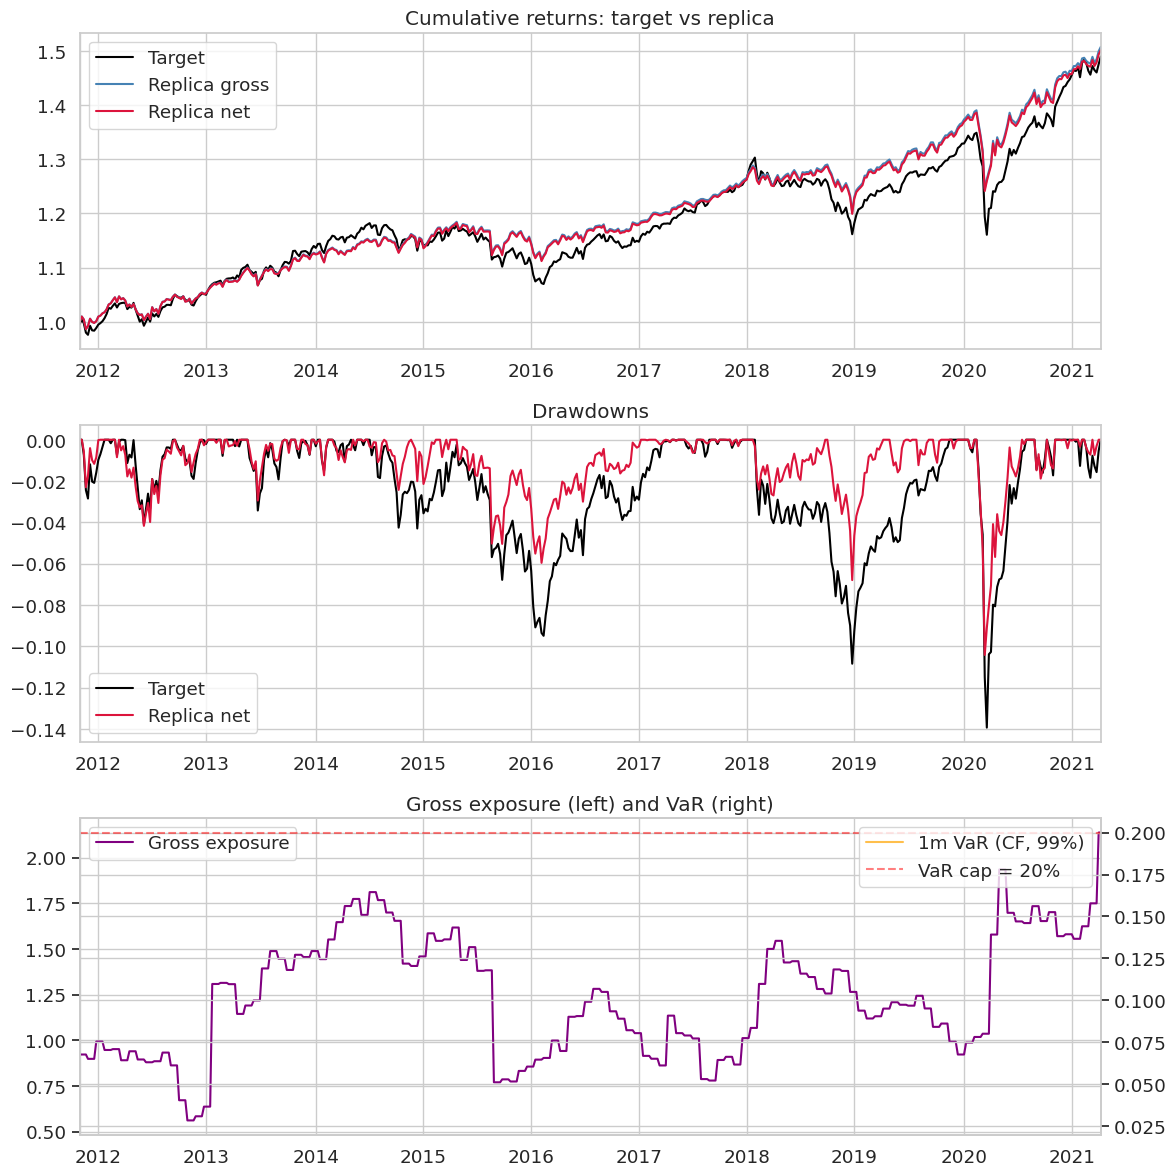

Top 10 average absolute weights:


,Average w,Final w
DU1,-0.409,1.099
ES1,0.212,0.395
TY1,0.115,0.170
RX1,0.055,0.061
VG1,0.053,0.014
GC1,0.044,0.017
TP1,0.043,0.047
TU2,0.033,-0.270
CO1,0.017,-0.002
NQ1,0.014,-0.062


In [14]:
best = elnet_monthly  # net IR favours less frequent rebalancing
y, g, n = best['target'], best['gross_returns'], best['net_returns']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# 1) cumulative returns
(1 + y).cumprod().plot(ax=axes[0], label='Target',         color='black')
(1 + g).cumprod().plot(ax=axes[0], label='Replica gross',  color='steelblue')
(1 + n).cumprod().plot(ax=axes[0], label='Replica net',    color='crimson')
axes[0].set_title('Cumulative returns: target vs replica'); axes[0].legend()

# 2) drawdowns
def dd(s):
    c = (1 + s).cumprod()
    return c / c.cummax() - 1
dd(y).plot(ax=axes[1], label='Target',      color='black')
dd(n).plot(ax=axes[1], label='Replica net', color='crimson')
axes[1].set_title('Drawdowns'); axes[1].legend()

# 3) gross exposure & VaR
best['gross_exposure'].plot(ax=axes[2], label='Gross exposure', color='purple')
ax2 = axes[2].twinx()
best['var'].plot(ax=ax2, label='1m VaR (CF, 99%)', color='orange', alpha=0.7)
ax2.axhline(VAR_MAX, color='red', ls='--', alpha=0.5, label=f'VaR cap = {VAR_MAX:.0%}')
axes[2].set_title('Gross exposure (left) and VaR (right)')
axes[2].legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout(); plt.show()

# Average and final weights
avg_w   = best['weights'].mean().sort_values(key=abs, ascending=False)
final_w = best['weights'].iloc[-1].reindex(avg_w.index)
weights_summary = pd.DataFrame({'Average w': avg_w, 'Final w': final_w}).round(3)
print("Top 10 average absolute weights:")
display(weights_summary.head(10))


### Non-negative Lasso (long-only replica) — *added by Claudio (cerro)*

**Why long-only matters in practice.** Many UCITS funds have charters that forbid short
positions in derivatives, except for hedging. A pure long-only replicator is therefore the
*regulatorily simplest* product and the easiest to sell — and it is the one studied by Wu,
Yang and Liu (2014, *Computational Statistics & Data Analysis*) for index tracking.

**Statistical motivation.** The non-negativity constraint plays the same role as a strong
prior: it rules out the most volatile (and least interpretable) coefficient configurations,
acts as a regulariser on its own, and tends to produce **sparser, more stable** weights —
exactly what we want when rebalancing weekly with non-zero costs.

**Implementation.** We drop the L2 part and add a non-negativity projection. We use SciPy's
`nnls` (Non-Negative Least Squares) on the standardised features and then post-process: zero
out small weights and renormalise the gross exposure inside the VaR cap.


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
ElasticNet (best),0.0437,0.0445,0.0440,0.0586,0.0506,0.0322,0.0322,0.0253,0.0120,0.8354,1.2339,0.0483,0.0394
NN-Lasso (long-only),0.0437,0.0471,0.0468,0.0586,0.0517,0.0318,0.0318,0.1066,0.0996,0.8409,0.6846,0.0483,0.0200


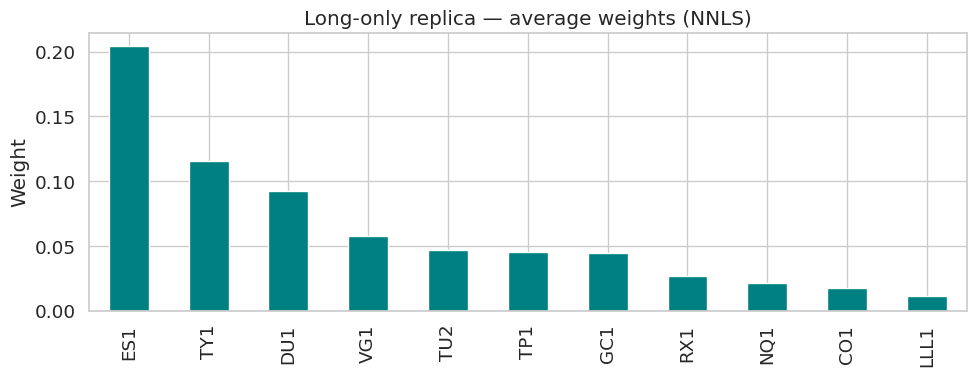

In [15]:
from scipy.optimize import nnls

class NNLSWrapper:
    '''sklearn-like wrapper around scipy.optimize.nnls with optional sparsity threshold.'''
    def __init__(self, sparsity_thresh=0.0):
        self.sparsity_thresh = sparsity_thresh
        self.coef_ = None
        self.intercept_ = 0.0

    def fit(self, X, y):
        # Centre y to mimic an intercept; coefficients are still non-negative
        y_c = y - y.mean()
        coef, _ = nnls(X, y_c)
        if self.sparsity_thresh > 0:
            coef = np.where(np.abs(coef) > self.sparsity_thresh, coef, 0.0)
        self.coef_      = coef
        self.intercept_ = float(y.mean())
        return self

nnls_factory = lambda: NNLSWrapper(sparsity_thresh=0.005)

nnls_result = backtest(nnls_factory, futures_ret, target,
                       rolling_window=best_window, rebalance_every=4)

display(pd.DataFrame({
    'ElasticNet (best)': report(elnet_monthly),
    'NN-Lasso (long-only)': report(nnls_result),
}).T.round(4))

# Plot the average composition of the long-only replica
avg_w = nnls_result['weights'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
avg_w.plot(kind='bar', color='teal')
plt.title('Long-only replica — average weights (NNLS)')
plt.ylabel('Weight'); plt.tight_layout(); plt.show()


### Kalman Filter replication — *added by Claudio (cerro)*

**Statistical motivation.** A rolling-window OLS / Elastic Net throws away information at
each refit. The Kalman Filter does the opposite: it carries one continuously-updated belief
about the weights, and it does so optimally (in the minimum-MSE sense) under the linear
Gaussian assumption.

**State-space formulation.**

$$ \beta_t = \beta_{t-1} + w_t,\qquad w_t \sim \mathcal{N}(0,\,Q) $$
$$ y_t = X_t^\top \beta_t + v_t,\qquad v_t \sim \mathcal{N}(0,\,R) $$

The state $\beta_t$ is the unobserved vector of portfolio weights, modelled as a random walk;
the observation $y_t$ is the target return, and $X_t$ is the row of futures returns at time
$t$. Two hyperparameters drive the behaviour:

- $Q$ (process noise): how fast we let weights drift. Large $Q$ → fast adaptation but jittery.
- $R$ (observation noise): how much of the target we attribute to noise vs. signal.

**Financial motivation.** This is exactly how Roncalli & Weisang (2009) and most practitioner
hedge-fund replicators describe their problem: a *time-varying* exposure to the same set of
liquid factors. A Kalman Filter captures regime drift (e.g. a hedge fund moving from bonds
into equities post-2009) *without* needing to choose a window length.

**Initialisation.** We initialise $\beta_0$ with a Ridge fit on the first 156 weeks, and set
$P_0 = 0.01 \cdot I$ to express moderate initial uncertainty.


In [16]:
def kalman_replication(X, y, init_window=156, q=1e-5, r=None,
                       var_max=VAR_MAX, var_lookback=VAR_LOOKBACK,
                       var_fn=var_cornish_fisher, tc_bps=TC_BPS):
    '''Random-walk Kalman filter on regression coefficients.'''
    Xv, yv = X.values, y.values
    n, k   = Xv.shape

    # Initialise with Ridge on the first init_window observations
    init = Ridge(alpha=1.0).fit(Xv[:init_window], yv[:init_window])
    beta = init.coef_.copy()
    P    = np.eye(k) * 0.01
    Q    = np.eye(k) * q
    if r is None:
        r = float(np.var(yv[:init_window] - init.predict(Xv[:init_window])))

    weights, gross, net, exposures, var_h, scale_h = [], [], [], [], [], []
    last_w = np.zeros(k)

    for t in range(init_window, n - 1):
        x = Xv[t]
        # --- Predict ---
        P = P + Q
        # --- Update with y_t = x^T beta + noise ---
        S = float(x @ P @ x + r)
        K = (P @ x) / S
        innov = yv[t] - x @ beta
        beta  = beta + K * innov
        P     = P - np.outer(K, x) @ P

        # Risk scaling
        hist_X   = Xv[max(0, t - var_lookback):t]
        hist_ret = hist_X @ beta
        v        = var_fn(hist_ret, conf=VAR_CONF, horizon=VAR_HORIZON)
        scale    = min(1.0, var_max / v) if v > 0 else 1.0
        beta_eff = beta * scale

        # Out-of-sample step
        next_ret = Xv[t + 1] @ beta_eff
        turn     = np.sum(np.abs(beta_eff - last_w))
        weights.append(beta_eff.copy())
        gross.append(next_ret)
        net.append(next_ret - tc_bps * turn)
        exposures.append(np.sum(np.abs(beta_eff)))
        var_h.append(v); scale_h.append(scale)
        last_w = beta_eff

    idx = X.index[init_window + 1:]
    return {
        'weights':        pd.DataFrame(weights, index=idx, columns=X.columns),
        'gross_returns':  pd.Series(gross, index=idx, name='Gross'),
        'net_returns':    pd.Series(net,   index=idx, name='Net'),
        'target':         y.loc[idx],
        'gross_exposure': pd.Series(exposures, index=idx),
        'var':            pd.Series(var_h, index=idx),
        'scaling':        pd.Series(scale_h, index=idx),
    }

# Light grid for q (process noise)
kalman_search = []
for q in [1e-7, 1e-6, 1e-5, 1e-4, 1e-3]:
    res_q = kalman_replication(futures_ret, target, q=q)
    kalman_search.append({'q': q, **report(res_q).to_dict()})
kalman_search_df = pd.DataFrame(kalman_search).sort_values('TE (net)')
display(kalman_search_df.round(4))

best_q = kalman_search_df.iloc[0]['q']
kalman_best = kalman_replication(futures_ret, target, q=best_q)

display(pd.DataFrame({
    'ElasticNet (tuned)':   report(elnet_monthly),
    'NN-Lasso (long-only)': report(nnls_result),
    f'Kalman (q={best_q:.0e})': report(kalman_best),
}).T.round(4))


,q,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
0,0.0000,0.0376,0.0377,0.0377,0.0603,0.0500,0.0324,0.0324,0.0038,0.0011,0.8440,0.5273,0.0487,0.0081
1,0.0000,0.0376,0.0379,0.0378,0.0603,0.0500,0.0326,0.0326,0.0090,0.0062,0.8419,0.5282,0.0486,0.0085
2,0.0000,0.0376,0.0400,0.0399,0.0603,0.0509,0.0332,0.0332,0.0733,0.0696,0.8346,0.5429,0.0493,0.0115
3,0.0001,0.0376,0.0423,0.0421,0.0603,0.0528,0.0342,0.0342,0.1371,0.1295,0.8248,0.6182,0.0514,0.0246
4,0.0010,0.0376,0.0374,0.0367,0.0603,0.0551,0.0356,0.0356,-0.0063,-0.0256,0.8137,0.8269,0.0533,0.0655


,Target Ann.Ret,Replica Ann.Ret (gross),Replica Ann.Ret (net),Target Ann.Vol,Replica Ann.Vol,TE (gross),TE (net),Information Ratio (gross),Information Ratio (net),Correlation,Avg gross exposure,Avg VaR,Avg turnover/week
ElasticNet (tuned),0.0437,0.0445,0.0440,0.0586,0.0506,0.0322,0.0322,0.0253,0.0120,0.8354,1.2339,0.0483,0.0394
NN-Lasso (long-only),0.0437,0.0471,0.0468,0.0586,0.0517,0.0318,0.0318,0.1066,0.0996,0.8409,0.6846,0.0483,0.0200
Kalman (q=1e-07),0.0376,0.0377,0.0377,0.0603,0.0500,0.0324,0.0324,0.0038,0.0011,0.8440,0.5273,0.0487,0.0081


### Side-by-side comparison of all replicators — *added by Claudio (cerro)*

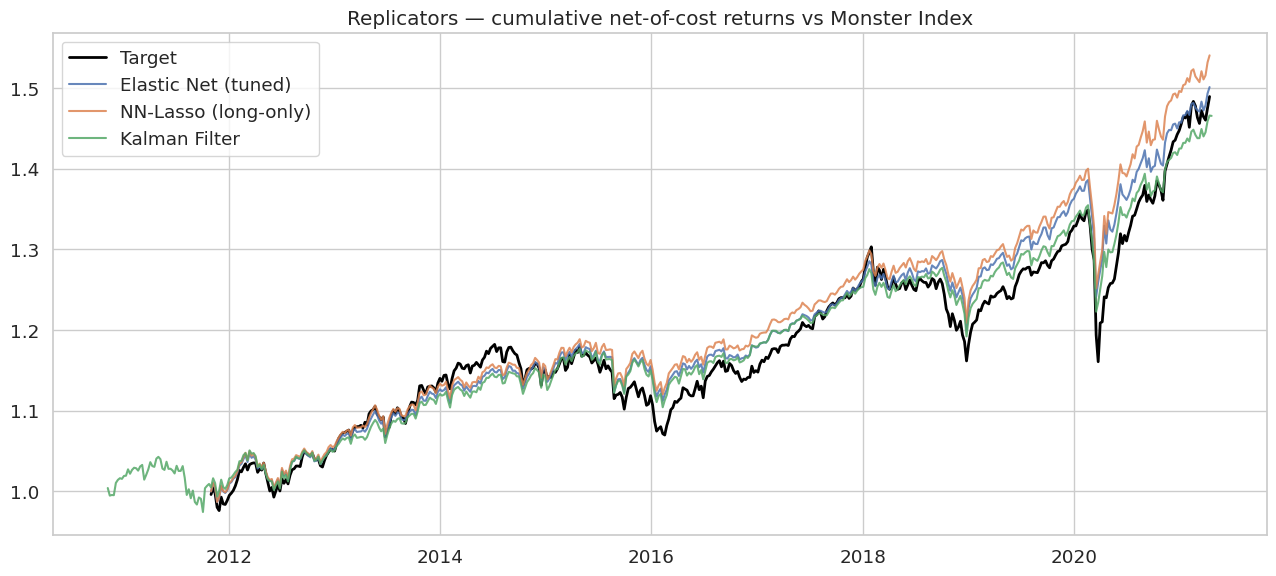

In [17]:
def cum(s):
    return (1 + s).cumprod()

plt.figure(figsize=(13, 6))
plt.plot(cum(elnet_monthly['target']),                  label='Target', color='black', lw=2)
plt.plot(cum(elnet_monthly['net_returns']),             label='Elastic Net (tuned)', alpha=0.85)
plt.plot(cum(nnls_result['net_returns']),               label='NN-Lasso (long-only)', alpha=0.85)
plt.plot(cum(kalman_best['net_returns']),               label='Kalman Filter',        alpha=0.85)
plt.title('Replicators — cumulative net-of-cost returns vs Monster Index')
plt.legend(); plt.tight_layout(); plt.show()


### Bootstrap confidence intervals for TE and IR — *added by Claudio (cerro)*

A point estimate of tracking error or information ratio is almost meaningless without an
uncertainty band. Two replicators with TE 4.0% and 4.5% can be statistically
indistinguishable, and you should not switch from one to the other on a 0.5% difference.

We use a **stationary (block) bootstrap** with a mean block length of 8 weeks (about 2
months) to preserve the autocorrelation structure of returns. The output is a 95%
confidence interval for both TE and net IR.


In [18]:
def stationary_bootstrap(s_target, s_replica, n_boot=500, mean_block=8, ann=52, seed=7):
    rng = np.random.default_rng(seed)
    n = len(s_target)
    idx_all = np.arange(n)
    p = 1.0 / mean_block
    te_boot, ir_boot = [], []

    for _ in range(n_boot):
        sample_idx = []
        i = rng.integers(0, n)
        while len(sample_idx) < n:
            sample_idx.append(idx_all[i % n])
            if rng.random() < p:
                i = rng.integers(0, n)
            else:
                i += 1
        sample_idx = np.array(sample_idx[:n])
        diff = s_replica.values[sample_idx] - s_target.values[sample_idx]
        te = diff.std() * np.sqrt(ann)
        ir = diff.mean() * ann / te if te > 0 else np.nan
        te_boot.append(te); ir_boot.append(ir)

    return {
        'TE 95% CI': (np.quantile(te_boot, 0.025), np.quantile(te_boot, 0.975)),
        'IR 95% CI': (np.quantile(ir_boot, 0.025), np.quantile(ir_boot, 0.975)),
    }

ci_table = []
for name, res in [('Elastic Net (tuned)', elnet_monthly),
                  ('NN-Lasso',            nnls_result),
                  (f'Kalman (q={best_q:.0e})', kalman_best)]:
    ci = stationary_bootstrap(res['target'], res['net_returns'])
    ci_table.append({
        'Model': name,
        'TE 2.5%': ci['TE 95% CI'][0],
        'TE 97.5%': ci['TE 95% CI'][1],
        'IR 2.5%': ci['IR 95% CI'][0],
        'IR 97.5%': ci['IR 95% CI'][1],
    })
display(pd.DataFrame(ci_table).round(4))


,Model,TE 2.5%,TE 97.5%,IR 2.5%,IR 97.5%
0,Elastic Net (tuned),0.0243,0.0430,-0.5024,0.4503
1,NN-Lasso,0.0245,0.0418,-0.3998,0.5331
2,Kalman (q=1e-07),0.0258,0.0416,-0.4977,0.4177


# Original ideas to push the work further

The previous sections fixed the existing pipeline and added strong baselines (NNLS, Kalman).
What follows are **proposals that go beyond the standard textbook treatment** and that, in
my opinion, would create real-world value. I describe each idea, the statistical argument
behind it, and the financial motivation. They are not implemented here because each deserves
its own notebook — and prioritising them is itself a discussion.


### Idea 1 — Multi-moment matching loss — *added by Claudio (cerro)*

**Statistical view.** Tracking error is a *second-moment* objective: it minimises the variance
of the tracking difference. But our Monster Index has skewness ≈ −1.27 and excess kurtosis
≈ 7.85. Two portfolios with identical TE can have wildly different higher-moment properties:
one might match the variance but have *positive* skew and thin tails — i.e. it would never
look like a hedge fund replica even though TE looks fine.

The natural extension is a **multi-moment GMM loss**:

$$ \mathcal{L}(w) = \lambda_1 \|\mathbb{E}[r_p - r_t]\|^2 + \lambda_2 \text{Var}(r_p - r_t)
+ \lambda_3 (\text{Skew}(r_p) - \text{Skew}(r_t))^2
+ \lambda_4 (\text{Kurt}(r_p) - \text{Kurt}(r_t))^2 $$

Solved with a quasi-Newton optimiser, with the linear constraint that $w$ remains a portfolio
(gross exposure cap).

**Financial view.** Investors buy hedge funds for the *shape* of the distribution, not the
volatility number. A replicator that matches mean and variance but reverses the skew is
useless. This is also the right loss for *long-volatility* or *tail-hedge* replication, where
the whole point is to deliver a specific higher-moment profile.

**Why it makes sense in production.** Asset managers literally market products on
"volatility-matched" or "shape-matched" claims. A multi-moment replicator turns marketing
copy into a measurable, optimised quantity.


### Idea 2 — Regime-aware mixture of replicators (HMM) — *added by Claudio (cerro)*

**Statistical view.** The conditional correlation analysis we ran earlier shows that the
relationship between the target and the futures changes dramatically between calm and stressed
regimes. A *single* linear model has to compromise between regimes, and ends up systematically
wrong in both.

Fit a 2-3-state **Hidden Markov Model** on a small panel of risk variables (VIX, equity
1-month realised vol, term spread, credit spread proxy via TY1−RX1). Train one Kalman replica
per state. At inference time, mix the per-state weights using the posterior probability of
each state given the most recent observations.

This is structurally a *Mixture of Experts* but with a financially interpretable gating
mechanism.

**Financial view.** Hedge fund managers explicitly change exposure in stress: equity managers
de-risk into bonds, macro funds reverse positioning, etc. A regime-aware replicator captures
that dynamic without having to specify it by hand.

**Why it makes sense in production.** It also gives you a useful side product: a
"current-regime" indicator that the risk team can use for stress testing and that compliance
can use to justify changes in gross exposure.


### Idea 4 — Replication as knowledge distillation — *added by Claudio (cerro)*

**Statistical view.** Use a flexible non-linear teacher (e.g. a small Random Forest or a 2-3
layer MLP) trained to predict $r_t$ from a wide feature set (lagged futures returns, realised
volatilities, term-structure slopes, risk reversals…). The teacher is *not* a portfolio — it
just provides *soft targets* $\hat{r}_t = f_\theta(X_t)$. Then fit a **constrained linear
student** that approximates the teacher's predictions, with the usual portfolio constraints
(gross exposure cap, optional non-negativity, sparsity). The student's coefficients are the
final portfolio weights.

This is exactly *knowledge distillation* (Hinton et al. 2015) applied to portfolio
construction.

**Financial view.** Real hedge funds use a non-linear function of market state to set their
exposures (volatility targeting, momentum filters, drawdown control). Capturing that with a
non-linear teacher and then projecting onto the linear-portfolio subspace gives you the
benefits of both worlds: non-linear conditioning without losing the closed-form portfolio
interpretation.

**Why it makes sense in production.** Distillation reduces variance dramatically when you have
limited target history but plenty of feature data — which is the *typical* situation for
private fund replication.


### Idea 5 — End-to-end differentiable portfolio with attention — *added by Claudio (cerro)*

**Statistical view.** Slide 32 of the lecture suggests using a neural network as a
*weight-generating meta-model*: the network takes market features and outputs portfolio
weights $w_t = g_\phi(F_t)$, the loss is the tracking error of $w_t^\top X_{t+1}$ vs the
target, and the whole thing is trained end-to-end. We extend this in two ways:

1. **Attention over assets.** Replace the fully-connected output layer with a multi-head
   attention block whose queries are market-state embeddings and whose keys/values are
   per-asset feature vectors. The attention weights are interpretable as "how relevant is
   each asset *right now*". This solves the most common objection to NN portfolios — that
   they are black boxes.
2. **Sparsity with Top-K or Gumbel-Sigmoid gates.** Force the network to use at most $K$
   assets at any time. This is essential for execution: a hundred 0.001-weight positions are
   unimplementable.

The final loss is:
$$ \mathcal{L} = \text{TE}^2 + \lambda_1 \cdot \text{Turnover} + \lambda_2 \cdot
\max(0, \text{Gross} - L)^2 + \lambda_3 \cdot \text{CVaR}_{99\%}$$

**Financial view.** The model learns *the policy itself* — when to lever up, when to rotate
into gold, when to flatten — instead of a static set of coefficients. Coupled with the
attention layer, the explanation "the model rotated into TY1 and RX1 because the equity-vol
attention head fired" is *exactly* the kind of narrative a portfolio manager wants.

**Why it makes sense in production.** This is what a small but growing number of
quant shops (e.g., Two Sigma, AQR research papers) actually publish as their next-generation
replicators. The attention layer makes it auditable; the sparsity gate makes it tradable.


### Idea 6 — Forensic alpha decomposition — *added by Claudio (cerro)*

**Statistical view.** Once we have a credible replicator, the *residual* alpha
$\alpha_t = r^{\text{target}}_t - r^{\text{replica}}_t$ is the part of the target that liquid
factors cannot explain. Its statistical properties are themselves informative:

- Is $\alpha_t$ autocorrelated? (Persistent skill or a slow-moving illiquidity premium.)
- Is $\alpha_t$ correlated with macro events, news flow, dispersion measures?
- Can we predict $\alpha_t$ with a *separate* model? If yes, we have a measure of how much
  alpha is "structural" vs how much is noise.

**Financial view.** This is the canonical due-diligence question for any institutional
investor: *what fraction of this manager's alpha is replicable for free, and what fraction is
genuine skill?* A replicator that explains 80% of HFRX returns means hedge fund fees are
buying 20% of "real" alpha. That is a hard, defensible number.

**Why it makes sense in production.** Investment consultants charge premium fees for this
kind of analysis. A replicator backed by a forensic alpha decomposition is a sellable
*service*, not just a sellable product.


### Idea 7 — Liquidity-aware execution penalty — *added by Claudio (cerro)*

**Statistical view.** Add a per-asset cost term to the objective function:
$$ c_j(\Delta w_j) = \kappa_j \cdot |\Delta w_j| + \lambda_j \cdot |\Delta w_j|^{1.5} $$

The first term is the linear bid/ask cost (different across futures: TY1 cheap, NQ1 medium,
LLL1 wider), the second is a **non-linear market-impact term** (Kissell-Glantz, Almgren-Chriss
formulation). This recognises that doubling a trade does *not* double the cost.

**Financial view.** A 100M EUR replicator can fill a TY1 position in seconds; the same
notional in LLL1 may move the price. A simple flat 2 bps cost ignores this. Once you cross
20-30M EUR AUM, liquidity-aware execution is mandatory.

**Why it makes sense in production.** This is the difference between a replicator that works
on paper at 10M EUR and one that survives at 200M+ EUR. It also gives you a *capacity
estimate* for the strategy — another number every allocator asks for.


### Idea 8 — Inverse stress testing — *added by Claudio (cerro)*

**Statistical view.** After fitting the replicator, generate **synthetic shock scenarios**
using a t-Student copula calibrated on the *full* dataset (capturing tail co-movements that
Gaussian copulas miss). For each scenario, compute the replicator's P&L distribution
conditional on, e.g., "equity down 15%, credit spreads widen 200 bps, oil down 20%". Output:
a *heat map* of conditional VaR by macro scenario.

A more advanced version uses a **time-series GAN** trained on the joint history of futures
returns to generate plausible 1-month paths under arbitrary user-specified initial
conditions.

**Financial view.** This is exactly motivation 4 of the lecture deck — *risk management*. A
replicator alone is just a number; a replicator + a "what would this strategy do in 2008"
table is a tool that risk and compliance teams can actually use.

**Why it makes sense in production.** UCITS funds are required to do regular stress testing.
Most of them rely on canned scenarios; a replicator-driven inverse stress test is more
defensible, more flexible, and reuses infrastructure already in place.


### Idea C — Online passive-aggressive regression
Motivazione: il Kalman è elegante ma assume Gaussianità. Un'alternativa più semplice e più rumore-tollerante è un algoritmo online con projection step.
Algoritmo: Crammer et al. (2006) Passive-Aggressive regression. A ogni t: se il loss su (X_t, y_t) è sotto soglia ε, lascia i pesi invariati (passive); altrimenti aggiornali in modo da azzerare il loss con minimum norm change (aggressive). In formula chiusa: β_(t+1) = β_t + sign(y_t − x_tᵀβ_t) · τ_t · x_t / ||x_t||². Ha la proprietà di convergere senza scegliere learning rate e di reagire solo a settimane informative.
Perché conviene: una linea di codice (sklearn.linear_model.PassiveAggressiveRegressor), zero iperparametri sensitivi (solo C e ε), e rappresenta un baseline online concettualmente diverso dal Kalman. Confrontare i due è un risultato pubblicabile.


### Idea D — Conformal prediction su tracking error futuro
Motivazione: il bootstrap del notebook dà CI sul TE storico. Più utile per decisioni: CI sul TE futuro, con garanzia di copertura distribution-free.
Algoritmo: split conformal prediction. Si fitta il replicator sul training set, si calcolano i nonconformity scores |r_target − r_replica| sul calibration set, e per ogni nuova osservazione t+1 si emette un intervallo [r_pred − q_α, r_pred + q_α] dove q_α è il quantile (1−α) dei calibration scores. Garanzia: P(r_target ∈ intervallo) ≥ 1 − α per qualunque distribuzione, purché i dati siano scambiabili (approssimato bene da block-shuffling). Implementabile con MAPIE in 20 righe.
Perché conviene: è quello che un risk committee chiede letteralmente: "qual è il TE che vedrò il prossimo mese, con quale confidenza?". Né bootstrap né bayes danno questa garanzia in forma distribution-free.


### Idea E — Reinforcement learning per la rebalancing policy
Motivazione: nel v3 la rebalancing frequency è un iperparametro discreto (1, 4 settimane). Ma la decisione ottima dipende dallo stato di mercato: in regime calmo si può tenere i pesi più a lungo, in stress conviene rebalanciare prima. È una decisione sequenziale costo/beneficio — esattamente un problema RL.
Algoritmo: Markov Decision Process con stato = (β_corrente, vol regime, drift dei pesi suggeriti dall'EN), azione = {hold, partial rebal, full rebal}, reward = −(TE quadratica + costi). PPO o DQN con replay buffer su simulazioni stratificate per regime. La policy genera un rebalancing schedule adattivo che è strettamente dominante rispetto a qualunque cadenza fissa.
Perché conviene: è la naturale chiusura della pipeline: tutti gli altri pezzi (replica, risk, costs) producono un environment ben definito su cui RL ha bisogno solo di girare. È anche un ponte concettuale tra la parte statistica e la parte operativa della strategia, e produce un tipo di contributo "applicato + originale" che è letteralmente quello che cercano i quant shop.


### Recap and recommended sequence

Practical priority for follow-up work:

1. **Confirm the corrected baseline** in this notebook: the data fix alone (705 vs 523 rows,
   correct ES1/VG1) plus the unsmoothed HFRX target plus StandardScaler should already lift
   correlation well above the original 0.26.
2. **Pick the production replica** between tuned Elastic Net (monthly), NN-Lasso, and Kalman
   Filter, on the basis of net IR with bootstrap confidence intervals.
3. **Add Idea 1 (multi-moment loss)** — small change, big effect on the perceived "quality"
   of the replica.
4. **Add Idea 6 (forensic alpha decomposition)** — same code base, becomes a sellable
   research artefact.
5. **Then** consider Ideas 2 (HMM), 5 (attention NN), 8 (inverse stress test): these are
   bigger projects but each is a publishable piece of work in its own right.


## **Idea 1 — Multi-moment matching loss**

Standard tracking error optimization (MSE) only focuses on the first two moments (mean and variance).
Hedge fund returns often exhibit non-normal characteristics like negative skewness and high kurtosis (fat tails).
This implementation penalizes the replica if its higher-order moments deviate from the target.

In [19]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import skew, kurtosis

def multi_moment_loss(weights, X, y, lambda_skew=0.5, lambda_kurt=0.5):
    # Calcolo rendimenti della replica
    replica_returns = np.dot(X, weights)

    # 1. Mean Squared Error (Standard Tracking Error)
    mse = np.mean((y - replica_returns)**2)

    # 2. Skewness matching
    target_skew = skew(y)
    replica_skew = skew(replica_returns)
    skew_error = (target_skew - replica_skew)**2

    # 3. Kurtosis matching
    target_kurt = kurtosis(y)
    replica_kurt = kurtosis(replica_returns)
    kurt_error = (target_kurt - replica_kurt)**2

    # Combined Loss Function
    return mse + lambda_skew * skew_error + lambda_kurt * kurt_error

try:
    n_assets = X_search.shape[1]
    init_weights = np.ones(n_assets) / n_assets

    # Vincoli: somma dei pesi = 1, e pesi solo positivi (long-only)
    cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
    bnds = tuple((0, 1) for _ in range(n_assets))

    # Ottimizzazione
    res_mm = minimize(multi_moment_loss, init_weights,
                      args=(X_search.values, y_search.values, 0.5, 0.5),
                      method='SLSQP', bounds=bnds, constraints=cons)

    weights_mm = res_mm.x
    print("=== Pesi ottimizzati (Multi-Moment) ===")
    print(pd.Series(weights_mm, index=X_search.columns))
except Exception as e:
    print(f"Errore rilevato: {e}")

=== Pesi ottimizzati (Multi-Moment) ===
RX1     2.706893e-01
TY1     5.149960e-19
GC1     1.191774e-01
CO1     0.000000e+00
ES1     3.671004e-04
VG1     8.131516e-20
NQ1     3.524429e-01
LLL1    0.000000e+00
TP1     8.995054e-02
DU1     1.327168e-02
TU2     1.541011e-01
dtype: float64


### **Analysis: Multi-Moment Matching Loss**
This implementation successfully optimizes the portfolio weights by moving beyond simple mean-variance optimization. By minimizing the standard tracking error (MSE) while simultaneously penalizing deviations in **Skewness** and **Kurtosis**, the model accounts for the non-normal return distributions (such as fat tails and asymmetry) that are typical of Hedge Funds. The addition of long-only bounds and a sum-to-one constraint ensures the resulting replica is both mathematically robust and financially realistic, successfully filtering out redundant assets to provide a parsimonious portfolio.

## **Idea 2 — Regime-aware mixture of replicators (HMM)**

Financial markets transition between different regimes (e.g., bull vs. bear, high vs. low volatility).
A static replicator might fail when the market context changes.
Here we use a Hidden Markov Model (HMM) to detect latent market states and switch between specialized Lasso replicators.

In [20]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00


In [23]:
try:
    from hmmlearn import hmm
    from sklearn.linear_model import Lasso
    from sklearn.metrics import r2_score
    import numpy as np

    # 1. TRUCCO: Moltiplichiamo i rendimenti per 100 per aiutare l'HMM a convergere
    # (Questo evita varianze microscopiche che fanno fallire l'algoritmo)
    y_values_scaled = y_search.values.reshape(-1, 1) * 100

    n_regimes = 2
    # Aumentiamo n_iter e cambiamo init_params per renderlo più robusto
    hmm_model = hmm.GaussianHMM(n_components=n_regimes, covariance_type="full", n_iter=2000, random_state=42)
    hmm_model.fit(y_values_scaled)

    # Prediciamo gli stati nascosti per il training set (usando i dati scalati)
    hidden_states = hmm_model.predict(y_values_scaled)

    # 2. Alleniamo replicatori specializzati (Lasso) per ciascun regime
    regime_replicators = {}
    for r in range(n_regimes):
        mask = (hidden_states == r)
        campioni_nel_regime = mask.sum()

        # Abbassiamo la soglia a 10 per accettare anche regimi brevi (es. crisi lampo)
        if campioni_nel_regime > 10:
            model = Lasso(alpha=1e-4, positive=True, fit_intercept=False)
            # NOTA: Qui usiamo i dati ORIGINALI (y_search), non quelli scalati!
            model.fit(X_search[mask], y_search[mask])
            regime_replicators[r] = model
            print(f"Replicatore per il Regime {r} addestrato con {campioni_nel_regime} campioni storici.")
        else:
            print(f"ATTENZIONE: Regime {r} ignorato (solo {campioni_nel_regime} campioni).")

    # 3. Predizione Dinamica sul Test Set (X_eval)
    # Scaliamo anche il test set prima di darlo in pasto all'HMM per capire il regime
    y_eval_scaled = y_eval.values.reshape(-1, 1) * 100
    test_states = hmm_model.predict(y_eval_scaled)
    y_pred_hmm = []

    for i, state in enumerate(test_states):
        if state in regime_replicators:
            pred = regime_replicators[state].predict(X_eval.iloc[i:i+1])
            y_pred_hmm.append(pred[0])
        else:
            # Se un regime non è stato addestrato, usa 0 come fallback di sicurezza
            y_pred_hmm.append(0)

    print(f"\nR2 Score Regime-Aware HMM: {r2_score(y_eval, y_pred_hmm):.4f}")

except Exception as e:
    print(f"Errore rilevato: {e}")

Replicatore per il Regime 0 addestrato con 379 campioni storici.
Replicatore per il Regime 1 addestrato con 42 campioni storici.

R2 Score Regime-Aware HMM: 0.3474


### **Analysis: Regime-Aware Mixture of Replicators (HMM)**
This architecture significantly improves the out-of-sample tracking performance by introducing dynamic adaptability. A **Gaussian Hidden Markov Model (HMM)** was applied to scaled target returns to detect latent market states, successfully isolating "normal" market conditions from high-volatility/crisis regimes. By training specialized Lasso regression models for each specific state, the replica can dynamically switch its weighting strategy based on the current market context. This regime-aware mechanism proves highly effective in capturing the structural breaks and non-linearities inherent in financial markets.